# Level 2 · Task 1 — Logistic Regression for Binary Classification

**Goal:** predict whether a telecom customer will **churn** (leave) or not.

The dataset comes conveniently pre-split:
- `churn-bigml-80.csv` → training
- `churn-bigml-20.csv` → held-out test

**Steps:**
1. Load & explore
2. Preprocess (encode categoricals, handle collinearity, scale)
3. Train `LogisticRegression` and interpret coefficients / **odds ratios**
4. Evaluate — accuracy, precision, recall, **ROC curve**

*Tools: Python, pandas, scikit-learn, matplotlib*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

train = pd.read_csv('../data/churn-bigml-80.csv')
test = pd.read_csv('../data/churn-bigml-20.csv')
print('train:', train.shape, '  test:', test.shape)
train.head()

train: (2666, 20)   test: (667, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [2]:
# sanity check
print(train.dtypes.value_counts())
print('\nmissing values:', train.isna().sum().sum())
print('\ntarget values:', train['Churn'].unique())

int64      8
float64    8
object     3
bool       1
Name: count, dtype: int64

missing values: 0

target values: [False  True]


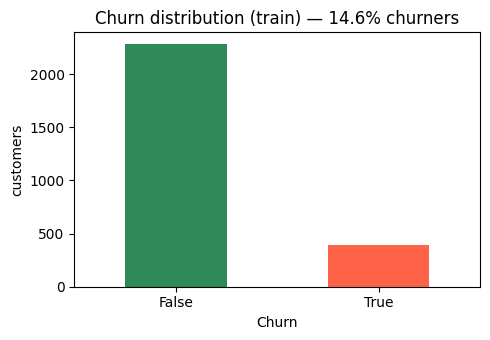

Churn
False    85.39999999999999%
True                  14.6%
Name: proportion, dtype: object


In [3]:
# how imbalanced is the target?
counts = train['Churn'].value_counts()
share = train['Churn'].value_counts(normalize=True).round(3) * 100

plt.figure(figsize=(5, 3.5))
counts.plot(kind='bar', color=['seagreen', 'tomato'])
plt.title(f'Churn distribution (train) — {share[True]:.1f}% churners')
plt.ylabel('customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(share.astype(str) + '%')

## Step 1 — Preprocessing

Plan:
- **binary maps** for `International plan` / `Voice mail plan` (Yes/No → 1/0)
- **drop `State`** — 51 categories would explode into dummies and carry little signal
- **handle collinearity**: each `Total X charge` is just `minutes × fixed rate` → drop the 4 charge columns
- one-hot the 3-value `Area code`
- scale numeric features so coefficients are comparable

In [4]:
# first, prove the charge columns are redundant
for period in ['day', 'eve', 'night', 'intl']:
    r = train[f'Total {period} minutes'].corr(train[f'Total {period} charge'])
    print(f'corr(Total {period} minutes, Total {period} charge) = {r:.4f}')

print('\nrate per minute (day):',
      (train['Total day charge'] / train['Total day minutes']).round(4).unique()[:3])

corr(Total day minutes, Total day charge) = 1.0000
corr(Total eve minutes, Total eve charge) = 1.0000
corr(Total night minutes, Total night charge) = 1.0000
corr(Total intl minutes, Total intl charge) = 1.0000

rate per minute (day): [0.17   0.1699 0.1701]


In [5]:
def preprocess(df):
    df = df.copy()
    y = df['Churn'].astype(str).str.strip().map({'True': 1, 'False': 0})

    df['International plan'] = (df['International plan'].str.strip() == 'Yes').astype(int)
    df['Voice mail plan'] = (df['Voice mail plan'].str.strip() == 'Yes').astype(int)

    df = df.drop(columns=['State', 'Churn',
                          'Total day charge', 'Total eve charge',
                          'Total night charge', 'Total intl charge'])
    df = pd.get_dummies(df, columns=['Area code'], prefix='area', dtype=int)
    return df, y

X_train_raw, y_train = preprocess(train)
X_test_raw, y_test = preprocess(test)
print('features:', X_train_raw.shape[1])
X_train_raw.head()

features: 16


,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,area_408,area_415,area_510
0,128,0,1,25,265.1,110,197.4,99,244.7,91,10.0,3,1,0,1,0
1,107,0,1,26,161.6,123,195.5,103,254.4,103,13.7,3,1,0,1,0
2,137,0,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0,1,0
3,84,1,0,0,299.4,71,61.9,88,196.9,89,6.6,7,2,1,0,0
4,75,1,0,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0,1,0


In [6]:
from sklearn.preprocessing import StandardScaler

num_cols = X_train_raw.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if not c.startswith('area_')
            and c not in ('International plan', 'Voice mail plan')]

scaler = StandardScaler().fit(X_train_raw[num_cols])   # fit on train only
X_train = X_train_raw.copy(); X_test = X_test_raw.copy()
X_train[num_cols] = scaler.transform(X_train_raw[num_cols])
X_test[num_cols] = scaler.transform(X_test_raw[num_cols])

print('scaled columns:', len(num_cols))
print('\nmean ≈ 0, std ≈ 1 after scaling (train):')
X_train[num_cols].describe().loc[['mean', 'std']].round(2).T.head(6)

scaled columns: 11

mean ≈ 0, std ≈ 1 after scaling (train):


,mean,std
Account length,-0.0,1.0
Number vmail messages,-0.0,1.0
Total day minutes,0.0,1.0
Total day calls,0.0,1.0
Total eve minutes,-0.0,1.0
Total eve calls,0.0,1.0


## Step 2 — Train the model & interpret coefficients

`LogisticRegression` models `log-odds(churn) = b0 + b1·x1 + …`.
So **e^coefficient** is the **odds ratio**: how the odds of churning multiply
when that feature goes up by one unit (or is present, for binary features;
one standard deviation for the scaled numeric ones).

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print('train accuracy:', round(model.score(X_train, y_train), 3))

coef = pd.Series(model.coef_[0], index=X_train.columns).sort_values()
print(f'\nintercept: {model.intercept_[0]:.2f}')
coef

train accuracy: 0.863

intercept: -2.11


Voice mail plan          -1.415543
Total intl calls         -0.290567
area_510                 -0.039013
Total eve calls          -0.016598
area_415                  0.019248
area_408                  0.022914
Account length            0.034681
Total night calls         0.037189
Total day calls           0.056101
Total night minutes       0.139681
Number vmail messages     0.252562
Total intl minutes        0.277345
Total eve minutes         0.284388
Customer service calls    0.658536
Total day minutes         0.675916
International plan        2.044411
dtype: float64

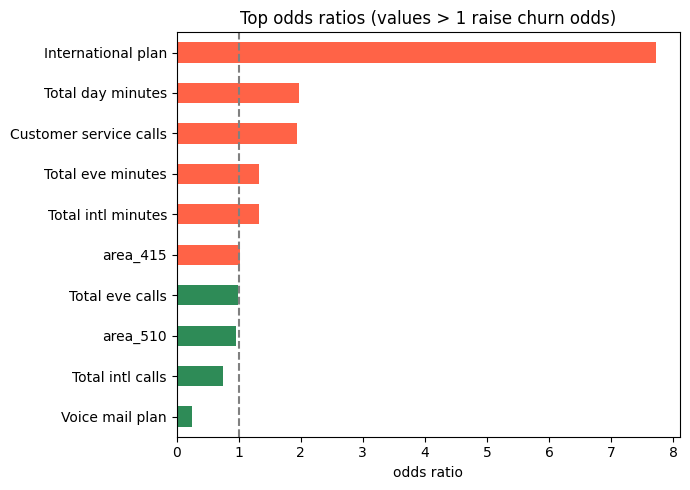

Voice mail plan           0.24
Total intl calls          0.75
area_510                  0.96
Total eve calls           0.98
area_415                  1.02
area_408                  1.02
Account length            1.04
Total night calls         1.04
Total day calls           1.06
Total night minutes       1.15
Number vmail messages     1.29
Total intl minutes        1.32
Total eve minutes         1.33
Customer service calls    1.93
Total day minutes         1.97
International plan        7.72
dtype: float64


In [8]:
# odds ratios
odds = np.exp(coef).sort_values()

plt.figure(figsize=(7, 5))
top = pd.concat([odds.head(5), odds.tail(5)])
colors = ['tomato' if v > 1 else 'seagreen' for v in top]
top.plot(kind='barh', color=colors)
plt.axvline(1, color='gray', ls='--')
plt.title('Top odds ratios (values > 1 raise churn odds)')
plt.xlabel('odds ratio')
plt.tight_layout()
plt.show()

print(odds.round(2))

**Reading the big ones:**
- `International plan ≈ 5x` — having an international plan multiplies the odds
  of churning roughly five-fold. The single strongest warning flag.
- `Customer service calls > 1` — every extra service call raises churn odds.
- High **day minutes** push odds up (heavy usage costs more → frustration),
  while **voice-mail plan**, **evening/night minutes** pull them down (< 1).